![Ironhack logo](https://user-images.githubusercontent.com/23629340/40541063-a07a0a8a-601a-11e8-91b5-2f13e4e6b441.png)

# 01 | Exploratory Data Analysis

*Project 1 — SQL: From Data to Insight*

**Team:**
**Dataset:**

---

Understanding your data before you design anything. You cannot decide which tables you need until you know which columns repeat, which are broken, and which identify a row.

> **Done when:** you can name the 3+ tables you are going to build, you have written down at least 2 research questions, and you know every data-quality problem notebook 02 will have to fix.

The sections below are a suggested route, not a form to fill in. Add sections, drop them, reorder them — what is graded is the analysis, not whether you kept the scaffold.

---
## 0. Setup

In [1]:
import sys
sys.path.append("..")          # so `src` is importable from inside notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.functions import *

pd.set_option("display.max_columns", 100)
sns.set_theme(style="whitegrid")

---
## 1. Load the raw data

Run `python download_data.py <payments|airbnb|retail>` from the repo root first. Your files land in `data/raw/`, which is gitignored.

In [3]:
data = pd.read_csv('../data/raw/Ecommerce_Recommendation_Dataset.csv')

df = data.copy()

---
## 2. First look

Shape, column types, a handful of rows. What is one row of this data?

In [10]:
shape_rows = df.shape[0]
shape_columns = df.shape[1]
column_types = df.dtypes

print(f"The dataset has {shape_columns} columns and {shape_rows} rows.")
print(f"Columns types \n {column_types}")

The dataset has 47 columns and 12000 rows.
Columns types 
 User_ID                           str
Item_ID                           str
Session_ID                        str
Age_Group                         str
Gender                            str
Membership_Level                  str
User_Activity_Score           float64
User_Loyalty_Score            float64
Average_Order_Value           float64
Past_Purchase_Count             int64
Item_Category                     str
Brand_Tier                        str
Item_Price                    float64
Discount_Percentage           float64
Item_Popularity_Score         float64
Item_Quality_Score            float64
Stock_Availability_Score      float64
Click_Count                     int64
View_Duration_Sec             float64
Cart_Add_Count                  int64
Wishlist_Flag                   int64
Purchase_Flag                   int64
Rating                        float64
Return_Flag                     int64
Engagement_Score             

In [ ]:
df.head(15)

,User_ID,Item_ID,Session_ID,Age_Group,Gender,Membership_Level,User_Activity_Score,User_Loyalty_Score,Average_Order_Value,Past_Purchase_Count,Item_Category,Brand_Tier,Item_Price,Discount_Percentage,Item_Popularity_Score,Item_Quality_Score,Stock_Availability_Score,Click_Count,View_Duration_Sec,Cart_Add_Count,Wishlist_Flag,Purchase_Flag,Rating,Return_Flag,Engagement_Score,Device_Type,Traffic_Source,Time_of_Day,Day_Type,Location_Zone,Context_Relevance_Score,User_Item_Affinity_Score,User_Node_Degree,Item_Node_Degree,Common_Neighbor_Count,Attention_Weight,Embedding_Similarity_Score,Candidate_Rank,Distance_Score,Retrieval_Latency_ms,Candidate_Recall_Score,Current_Ranking_Position,Q_Value_Score,Reward_Score,Ranking_Stability_Score,Final_Recommendation_Score,Recommendation_Action
0,USR_03175,ITM_01590,SES_002722,35-44,Male,Silver,0.626,0.269,24048.28,59,Home Decor,Standard,65903.78,14.36,0.647,0.962,0.302,3,122.85,1,1,0,4.9,0,0.4088,Mobile,Affiliate,Morning,Weekday,Metro,0.905,0.5774,18,27,62,0.6915,0.7110,91,0.3174,17.348,0.7081,14,0.5754,0.4453,0.6691,0.6769,Recommend
1,USR_00861,ITM_00900,SES_008315,18-24,Female,Silver,0.435,0.413,47366.62,56,Groceries,Budget,25721.96,11.17,0.665,0.918,0.850,2,324.52,0,0,0,4.0,0,0.2798,Desktop,Affiliate,Afternoon,Weekday,Metro,0.935,0.5383,217,18,40,0.6286,0.7246,84,0.3588,14.714,0.6439,32,0.6090,0.1811,0.6304,0.6334,Recommend
2,USR_01295,ITM_01502,SES_003254,25-34,Female,Basic,0.399,0.761,33175.42,11,Electronics,Standard,52375.39,51.86,0.419,0.637,0.278,3,241.95,0,1,1,4.0,0,0.4083,Mobile,Social Media,Afternoon,Weekday,Urban,0.562,0.5270,127,267,19,0.5218,0.6613,69,0.3979,14.900,0.6392,26,0.6462,0.7094,0.6352,0.6197,Soft Recommend
3,USR_01131,ITM_00223,SES_000789,55+,Male,Silver,0.209,0.487,67575.16,56,Sports,Budget,23233.95,51.90,0.585,0.914,0.275,2,12.66,0,0,0,4.5,0,0.0839,Desktop,Recommendation Feed,Afternoon,Weekend,Metro,0.517,0.4522,111,192,42,0.5691,0.7259,61,0.2532,30.077,0.6967,35,0.5566,0.1886,0.6584,0.5689,Soft Recommend
4,USR_01096,ITM_01077,SES_000257,25-34,Male,Silver,0.606,0.287,91442.53,39,Home Decor,Budget,5315.51,4.03,0.563,0.977,0.558,2,445.59,0,1,1,4.7,0,0.5142,Mobile,Direct,Evening,Weekday,Semi-Urban,0.814,0.5793,153,107,38,0.5340,0.6844,81,0.2920,19.347,0.6465,52,0.7017,0.7303,0.6889,0.6728,Recommend
5,USR_03093,ITM_01101,SES_004026,55+,Female,Basic,0.271,0.267,71614.95,9,Books,Standard,29408.25,16.57,0.054,0.689,0.568,3,8.98,0,1,0,4.1,0,0.2661,Mobile,Direct,Evening,Weekday,Urban,0.888,0.3012,83,96,16,0.3466,0.4959,52,0.5627,40.779,0.4475,38,0.4790,0.3529,0.4560,0.4883,Soft Recommend
6,USR_01639,ITM_01742,SES_005957,45-54,Female,Gold,0.627,0.451,94999.25,61,Beauty,Standard,12200.06,51.21,0.637,0.890,0.887,4,257.51,1,0,0,4.5,0,0.3618,Tablet,Recommendation Feed,Morning,Weekday,Urban,0.593,0.5952,133,99,35,0.5759,0.5955,38,0.3249,38.612,0.6363,49,0.5139,0.2213,0.5861,0.5398,Soft Recommend
7,USR_02170,ITM_00503,SES_006742,35-44,Male,Basic,0.675,0.586,37099.48,12,Fashion,Premium,67576.42,41.32,0.130,0.576,0.398,2,8.84,4,0,0,4.2,0,0.3044,Mobile,Social Media,Morning,Weekday,Urban,0.791,0.4693,137,206,69,0.4782,0.4695,91,0.5293,43.939,0.4612,38,0.3999,0.2982,0.4872,0.4792,Recommend
8,USR_00467,ITM_01340,SES_003655,25-34,Female,Basic,0.521,0.437,29171.36,61,Toys,Standard,84504.66,37.11,0.392,0.627,0.638,4,88.43,1,0,0,3.5,0,0.2572,Mobile,Search,Evening,Weekday,Urban,0.919,0.4536,92,234,70,0.6615,0.6133,30,0.4788,32.945,0.5806,22,0.5314,0.2028,0.5836,0.5936,Soft Recommend
9,USR_01239,ITM_00624,SES_007661,25-34,Male,Basic,0.281,0.878,20392.46,66,Automotive,Budget,25608.71,45.60,0.482,0.793,0.217,0,133.97,3,1,1,4.8,0,0.3845,Desktop,Email Campaign,Evening,Weekend,Rural,0.715,0.5613,72,294,78,0.5842,0.7652,38,0.2522,7.968,0.6836,57,0.8107,0.8347,0.7624,0.7239,Recommend


---
## 3. Data quality

Missing values, duplicates, numbers stored as text, dates stored as strings. Write down what you find — this is the to-do list for notebook 02.

In [19]:
# Checking the dataset for null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 47 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_ID                     12000 non-null  str    
 1   Item_ID                     12000 non-null  str    
 2   Session_ID                  12000 non-null  str    
 3   Age_Group                   12000 non-null  str    
 4   Gender                      12000 non-null  str    
 5   Membership_Level            12000 non-null  str    
 6   User_Activity_Score         12000 non-null  float64
 7   User_Loyalty_Score          12000 non-null  float64
 8   Average_Order_Value         12000 non-null  float64
 9   Past_Purchase_Count         12000 non-null  int64  
 10  Item_Category               12000 non-null  str    
 11  Brand_Tier                  12000 non-null  str    
 12  Item_Price                  12000 non-null  float64
 13  Discount_Percentage         12000 non-null

In [22]:
# Checking the dataset for missing values
df.isna().sum()

User_ID                       0
Item_ID                       0
Session_ID                    0
Age_Group                     0
Gender                        0
Membership_Level              0
User_Activity_Score           0
User_Loyalty_Score            0
Average_Order_Value           0
Past_Purchase_Count           0
Item_Category                 0
Brand_Tier                    0
Item_Price                    0
Discount_Percentage           0
Item_Popularity_Score         0
Item_Quality_Score            0
Stock_Availability_Score      0
Click_Count                   0
View_Duration_Sec             0
Cart_Add_Count                0
Wishlist_Flag                 0
Purchase_Flag                 0
Rating                        0
Return_Flag                   0
Engagement_Score              0
Device_Type                   0
Traffic_Source                0
Time_of_Day                   0
Day_Type                      0
Location_Zone                 0
Context_Relevance_Score       0
User_Ite

In [28]:
duplicated_rows = df.duplicated().sum()
if duplicated_rows > 0:
    print(f"Duplicate rows: {duplicated_rows}")
else:
    print("No duplicate rows in this data")


No duplicate rows in this data


In [33]:
spaced_values=df.eq(" ").sum()
spaced_values

User_ID                       0
Item_ID                       0
Session_ID                    0
Age_Group                     0
Gender                        0
Membership_Level              0
User_Activity_Score           0
User_Loyalty_Score            0
Average_Order_Value           0
Past_Purchase_Count           0
Item_Category                 0
Brand_Tier                    0
Item_Price                    0
Discount_Percentage           0
Item_Popularity_Score         0
Item_Quality_Score            0
Stock_Availability_Score      0
Click_Count                   0
View_Duration_Sec             0
Cart_Add_Count                0
Wishlist_Flag                 0
Purchase_Flag                 0
Rating                        0
Return_Flag                   0
Engagement_Score              0
Device_Type                   0
Traffic_Source                0
Time_of_Day                   0
Day_Type                      0
Location_Zone                 0
Context_Relevance_Score       0
User_Ite

In [35]:
quality = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "nulls": df.isna().sum(),
    "nulls_%": (df.isna().mean() * 100).round(1),
    "blanks": df.apply(lambda col: col.astype("string").str.strip().eq("").sum()),  # "", " ", "   "
    "n_unique": df.nunique(),
})

# keep only the columns that actually have a problem, worst first
quality[(quality["nulls"] > 0) | (quality["blanks"] > 0)].sort_values("nulls_%", ascending=False)

,dtype,nulls,nulls_%,blanks,n_unique


Notes: 
+ No missing values, all columns have the same number of rows
+ There are no duplicate rows
+ No columns have " " an empty space
+ There are no blanks

We can assume the dataset is mostly clean.

---
## 4. Distributions

The numeric columns you care about, and the outliers you will have to decide about.

In [36]:
num = df.select_dtypes(include="number")
num

,User_Activity_Score,User_Loyalty_Score,Average_Order_Value,Past_Purchase_Count,Item_Price,Discount_Percentage,Item_Popularity_Score,Item_Quality_Score,Stock_Availability_Score,Click_Count,View_Duration_Sec,Cart_Add_Count,Wishlist_Flag,Purchase_Flag,Rating,Return_Flag,Engagement_Score,Context_Relevance_Score,User_Item_Affinity_Score,User_Node_Degree,Item_Node_Degree,Common_Neighbor_Count,Attention_Weight,Embedding_Similarity_Score,Candidate_Rank,Distance_Score,Retrieval_Latency_ms,Candidate_Recall_Score,Current_Ranking_Position,Q_Value_Score,Reward_Score,Ranking_Stability_Score,Final_Recommendation_Score
0,0.626,0.269,24048.28,59,65903.78,14.36,0.647,0.962,0.302,3,122.85,1,1,0,4.9,0,0.4088,0.905,0.5774,18,27,62,0.6915,0.7110,91,0.3174,17.348,0.7081,14,0.5754,0.4453,0.6691,0.6769
1,0.435,0.413,47366.62,56,25721.96,11.17,0.665,0.918,0.850,2,324.52,0,0,0,4.0,0,0.2798,0.935,0.5383,217,18,40,0.6286,0.7246,84,0.3588,14.714,0.6439,32,0.6090,0.1811,0.6304,0.6334
2,0.399,0.761,33175.42,11,52375.39,51.86,0.419,0.637,0.278,3,241.95,0,1,1,4.0,0,0.4083,0.562,0.5270,127,267,19,0.5218,0.6613,69,0.3979,14.900,0.6392,26,0.6462,0.7094,0.6352,0.6197
3,0.209,0.487,67575.16,56,23233.95,51.90,0.585,0.914,0.275,2,12.66,0,0,0,4.5,0,0.0839,0.517,0.4522,111,192,42,0.5691,0.7259,61,0.2532,30.077,0.6967,35,0.5566,0.1886,0.6584,0.5689
4,0.606,0.287,91442.53,39,5315.51,4.03,0.563,0.977,0.558,2,445.59,0,1,1,4.7,0,0.5142,0.814,0.5793,153,107,38,0.5340,0.6844,81,0.2920,19.347,0.6465,52,0.7017,0.7303,0.6889,0.6728
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,0.716,0.577,78629.26,0,83537.26,48.73,0.827,0.984,0.552,1,264.41,2,1,1,4.8,0,0.4845,0.191,0.7188,129,23,56,0.5196,0.5887,33,0.4037,8.093,0.6125,30,0.5447,0.7956,0.5853,0.5448
11996,0.381,0.193,45451.21,59,77826.45,52.63,0.344,0.848,0.750,4,307.22,2,1,1,4.4,0,0.5588,0.705,0.4447,69,195,42,0.5119,0.6100,27,0.3753,21.294,0.5060,32,0.6609,0.7835,0.6302,0.6135
11997,0.265,0.133,73637.16,12,58896.08,51.51,0.255,0.365,0.330,4,139.32,1,0,0,2.8,0,0.2599,0.910,0.2511,35,190,4,0.4610,0.3179,35,0.6220,20.052,0.3488,48,0.3366,0.1611,0.3586,0.4134
11998,0.174,0.566,23296.92,24,23618.69,36.37,0.116,0.460,0.318,5,277.71,0,1,1,3.8,0,0.4617,0.627,0.3462,199,252,2,0.3383,0.4141,51,0.6537,39.188,0.3823,11,0.5256,0.6836,0.5009,0.4722


In [37]:
num.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   User_Activity_Score         12000 non-null  float64
 1   User_Loyalty_Score          12000 non-null  float64
 2   Average_Order_Value         12000 non-null  float64
 3   Past_Purchase_Count         12000 non-null  int64  
 4   Item_Price                  12000 non-null  float64
 5   Discount_Percentage         12000 non-null  float64
 6   Item_Popularity_Score       12000 non-null  float64
 7   Item_Quality_Score          12000 non-null  float64
 8   Stock_Availability_Score    12000 non-null  float64
 9   Click_Count                 12000 non-null  int64  
 10  View_Duration_Sec           12000 non-null  float64
 11  Cart_Add_Count              12000 non-null  int64  
 12  Wishlist_Flag               12000 non-null  int64  
 13  Purchase_Flag               12000 non-null

There are 33 numerical columns, but not all of them are needed for this analysis.

The following columns will be dropped from the dataset as they are redundant.
+ Engagement_Score	
+ Context_Relevance_Score	
+ User_Item_Affinity_Score	
+ User_Node_Degree	
+ Item_Node_Degree	
+ Common_Neighbor_Count	
+ Attention_Weight	
+ Embedding_Similarity_Score	
+ Candidate_Rank	
+ Distance_Score	
+ Retrieval_Latency_ms	
+ Candidate_Recall_Score	
+ Current_Ranking_Position	
+ Q_Value_Score	
+ Reward_Score	
+ Ranking_Stability_Score	
+ Final_Recommendation_Score 


---
## 5. Categorical columns

**This is the section that feeds tomorrow.** A column with few distinct values repeated over many rows is a lookup table waiting to happen. Find them.

In [41]:
cat = df.select_dtypes(exclude="number")
cat

,User_ID,Item_ID,Session_ID,Age_Group,Gender,Membership_Level,Item_Category,Brand_Tier,Device_Type,Traffic_Source,Time_of_Day,Day_Type,Location_Zone,Recommendation_Action
0,USR_03175,ITM_01590,SES_002722,35-44,Male,Silver,Home Decor,Standard,Mobile,Affiliate,Morning,Weekday,Metro,Recommend
1,USR_00861,ITM_00900,SES_008315,18-24,Female,Silver,Groceries,Budget,Desktop,Affiliate,Afternoon,Weekday,Metro,Recommend
2,USR_01295,ITM_01502,SES_003254,25-34,Female,Basic,Electronics,Standard,Mobile,Social Media,Afternoon,Weekday,Urban,Soft Recommend
3,USR_01131,ITM_00223,SES_000789,55+,Male,Silver,Sports,Budget,Desktop,Recommendation Feed,Afternoon,Weekend,Metro,Soft Recommend
4,USR_01096,ITM_01077,SES_000257,25-34,Male,Silver,Home Decor,Budget,Mobile,Direct,Evening,Weekday,Semi-Urban,Recommend
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11995,USR_00782,ITM_01587,SES_007471,25-34,Female,Gold,Beauty,Standard,Desktop,Social Media,Evening,Weekend,Urban,Recommend
11996,USR_02152,ITM_01453,SES_002675,35-44,Male,Basic,Electronics,Budget,Mobile,Email Campaign,Evening,Weekday,Urban,Recommend
11997,USR_02036,ITM_00120,SES_004549,45-54,Male,Platinum,Electronics,Standard,Mobile,Search,Afternoon,Weekday,Rural,Do Not Recommend
11998,USR_02387,ITM_01099,SES_001553,35-44,Female,Silver,Books,Budget,Mobile,Social Media,Night,Weekday,Metro,Soft Recommend


In [49]:
# User_ID, Item_ID and Session_ID even though marked as, aren't categorical values, they are Ids.
# In order to find the number of unique values in each categorical variable, we need to exclude the ID columns
id_cols = cat.columns[cat.columns.str.contains("ID")]

for col in cat:
    if col in id_cols:
        pass
    else:
        print(f"{col} ({df[col].nunique()} unique values):")
        print(df[col].value_counts())

Age_Group (5 unique values):
Age_Group
25-34    3932
18-24    2900
35-44    2647
45-54    1686
55+       835
Name: count, dtype: int64
Gender (3 unique values):
Gender
Female    6026
Male      5641
Other      333
Name: count, dtype: int64
Membership_Level (4 unique values):
Membership_Level
Basic       5145
Silver      3345
Gold        2445
Platinum    1065
Name: count, dtype: int64
Item_Category (10 unique values):
Item_Category
Electronics    1228
Toys           1227
Beauty         1223
Books          1213
Home Decor     1209
Health         1207
Fashion        1192
Groceries      1172
Automotive     1167
Sports         1162
Name: count, dtype: int64
Brand_Tier (4 unique values):
Brand_Tier
Standard    4751
Budget      3706
Premium     2582
Luxury       961
Name: count, dtype: int64
Device_Type (3 unique values):
Device_Type
Mobile     7869
Desktop    3334
Tablet      797
Name: count, dtype: int64
Traffic_Source (6 unique values):
Traffic_Source
Search                 3001
Social Medi

In [78]:
## Exploring the Item Categories with absolute and relative frequency -- whether they are balanced.

frequency_item_cat = cat.Item_Category.value_counts()
prorpotions_item_cat = cat.Item_Category.value_counts(normalize=True).round(2)
item_cat_df = pd.concat([frequency_item_cat, prorpotions_item_cat], axis=1)
item_cat_df.columns = ['absolute frequency', 'relative frequency']
item_cat_df

,absolute frequency,relative frequency
Item_Category,,
Electronics,1228,0.1
Toys,1227,0.1
Beauty,1223,0.1
Books,1213,0.1
Home Decor,1209,0.1
Health,1207,0.1
Fashion,1192,0.1
Groceries,1172,0.1
Automotive,1167,0.1


In [77]:
## Calculating the absolute and relative frequencies for Membership_Level to help us understand which is the most/least popular membership level and if they are evenly distributed.

frequency_membership = cat.Membership_Level.value_counts()
prorpotions_membership = cat.Membership_Level.value_counts(normalize=True).round(2)
membership_df = pd.concat([frequency_membership, prorpotions_membership], axis=1)
membership_df.columns = ['absolute frequency', 'relative frequency']
membership_df

,absolute frequency,relative frequency
Membership_Level,,
Basic,5145,0.43
Silver,3345,0.28
Gold,2445,0.20
Platinum,1065,0.09


/var/folders/zn/wkkkj_w57xl5nb23_t676b5w0000gn/T/ipykernel_18220/867439575.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


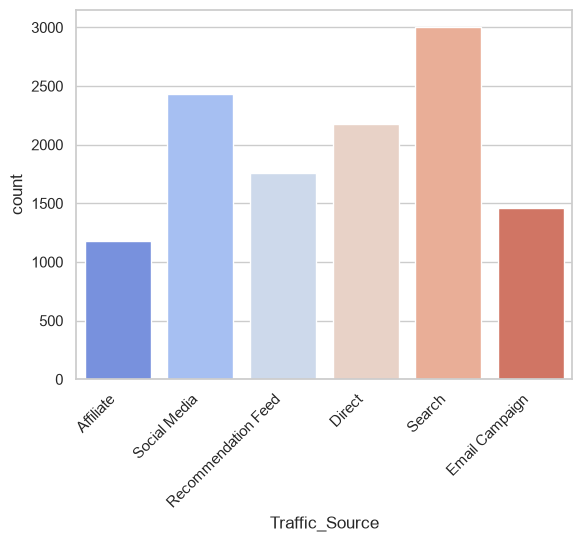

In [75]:
## Visualizing the traffic sources to spot if one source is more popular than another.

sns.countplot(
    data = cat,
    x = 'Traffic_Source',
    palette = 'coolwarm'
)
plt.xticks(rotation=45, ha='right')
plt.show()

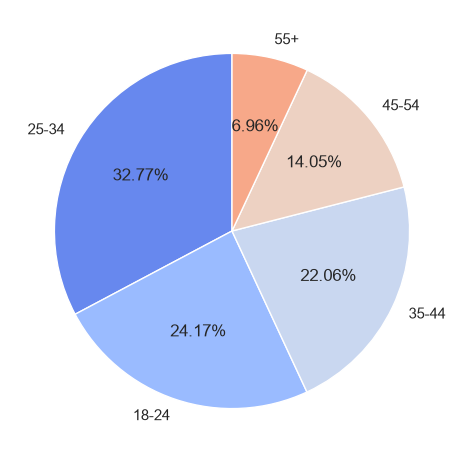

In [74]:
## Pie plot to visualize the distribution between the different age groups to understand if there is a more prevalent group.

frequency_age = cat.Age_Group.value_counts()

frequency_age.plot.pie(
    autopct='%1.2f%%' ,
    startangle=90,
    colors=sns.color_palette("coolwarm")
)
plt.tight_layout()
plt.show()



Findings: 
+ The item categories are very balanced
+ From the membership levels, we can notice that Basic holds the most frequency, and platinum the least. These are not very balanced.
+ The countplot shows the traffic sources are quite varied. Most of the traffic comes from search and social media and the least is through affiliate.
+ The pie plot shows that proportions between the age groups are quite close, between 25-34, 18-24 and 35-44. 


---
## 6. Research questions

At least two, written here. Specific, answerable with this data, and with an answer you could be wrong about. For each one, say what you expect and why.

1. Does the membership level and age group directly relate? Analyzing popularity in membership level across age group. The expectation is that "older" adults might have higher memberhip status.
2. Does membership level predict purchase conversion? Testing whether loyalty programs drive customer behavior. Would expect for membership level to drive the customer behavior.
3. Does customer rating impact purchase intent (purchase_flag)? Testing whether good ratings have higher purchase intent and vice versa. I would expect a direct relationship between the two variables.
4. Are there any product categories that are more popular for the different age groups? Expectating a difference in the relation between categories and age groups.

---
## 7. Into notebook 02

The tables you are going to build, and the problems you have to fix first.